# Predicción de cancelación de clientes (Churn) — Interconnect

**Objetivo del proyecto:** el operador de telecomunicaciones *Interconnect* quiere anticipar qué clientes tienen mayor probabilidad de cancelar su servicio, con el fin de ofrecerles códigos promocionales y planes especiales de retención de forma proactiva.

**Fuentes de datos:** cuatro tablas, todas identificadas por `customerID`:

| Tabla | Contenido | Filas |
|---|---|---|
| `contract.csv` | Tipo de contrato, fechas de alta/baja, forma de pago, cargos | 7,043 |
| `personal.csv` | Datos demográficos del cliente | 7,043 |
| `internet.csv` | Servicios de internet contratados | 5,517 |
| `phone.csv` | Servicio telefónico contratado | 6,361 |

**Variable objetivo:** `Churn` (1 = el cliente canceló el servicio, 0 = permanece activo), derivada del campo `EndDate`.

**Métricas de evaluación:** Exactitud (Accuracy), F1-score y ROC-AUC, dado que el problema es de clasificación binaria con clases desbalanceadas (predomina la clase "no cancela").

**Plan de trabajo:**
1. Carga e inspección de los datos
2. Integración de las tablas y construcción de la variable objetivo
3. Tratamiento de valores nulos y creación de variables adicionales
4. Análisis exploratorio de datos (EDA)
5. Preparación de variables para el modelado
6. Modelos base (parámetros por defecto)
7. Ajuste de hiperparámetros
8. Evaluación comparativa y selección del modelo final
9. Conclusiones y recomendaciones de negocio

## 1. Importación de librerías

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix
)

RANDOM_STATE = 42


## 2. Carga y exploración inicial de los datos

In [2]:
contract=pd.read_csv('contract.csv')
personal=pd.read_csv('personal.csv')
internet=pd.read_csv('internet.csv')
phone=pd.read_csv('phone.csv')

for name, d in [('contract', contract), ('personal', personal), ('internet', internet), ('phone', phone)]:
    print(f'{name:10s} -> {d.shape[0]} filas, {d.shape[1]} columnas')

contract   -> 7043 filas, 8 columnas
personal   -> 7043 filas, 5 columnas
internet   -> 5517 filas, 8 columnas
phone      -> 6361 filas, 2 columnas


Nótese que `internet` (5,517 filas) y `phone` (6,361 filas) tienen **menos** registros que `contract` y `personal` (7,043 filas cada una): no todos los clientes contrataron internet o telefonía. Esto es clave para decidir el tipo de *join* y para anticipar la aparición de valores nulos en el paso siguiente.

In [3]:
display(contract.head())
display(personal.head())
display(internet.head())
display(phone.head())

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


## 3. Inspección de calidad de datos (nulos y duplicados)

In [4]:
for name, d in [('contract', contract), ('personal', personal), ('internet', internet), ('phone', phone)]:
    print(f'--- {name} ---')
    print('Nulos:', d.isna().sum().sum())
    print('Duplicados:', d.duplicated().sum())
    print()

--- contract ---
Nulos: 0
Duplicados: 0

--- personal ---
Nulos: 0
Duplicados: 0

--- internet ---
Nulos: 0
Duplicados: 0

--- phone ---
Nulos: 0
Duplicados: 0



**No se encontraron valores nulos ni filas duplicadas en ninguna de las cuatro tablas originales.** Sin embargo, esta conclusión aplica únicamente a las tablas por separado: como `internet` y `phone` no cubren a todos los clientes, es *esperable* que aparezcan valores nulos al integrarlas con `contract` y `personal` mediante un `left join`. Esto se verifica en la siguiente sección.

## 4. Integración de las tablas y creación de la variable objetivo

Se usa `contract` como tabla base (contiene a los 7,043 clientes) y se integran `personal` (misma cobertura, `inner`/`merge` estándar), `internet` y `phone` mediante `left join`, para no perder clientes que no contrataron esos servicios.

In [5]:
df = (contract
      .merge(personal, on='customerID')
      .merge(internet, on='customerID', how='left')
      .merge(phone, on='customerID', how='left'))

# Variable objetivo: 1 si el cliente canceló (EndDate distinto de 'No'), 0 si sigue activo
df['Churn'] = np.where(df['EndDate'].astype(str).str.lower() == 'no', 0, 1)

# TotalCharges llega como texto (tiene celdas en blanco) -> se convierte a numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Forma del dataset integrado:', df.shape)
df.head()

Forma del dataset integrado: (7043, 21)


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,...,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,Churn
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,...,No,DSL,No,Yes,No,No,No,No,NaN,0
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.50,Male,0,...,No,DSL,Yes,No,Yes,No,No,No,No,0
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,...,No,DSL,Yes,Yes,No,No,No,No,No,1
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,...,No,DSL,Yes,No,Yes,Yes,No,No,NaN,0
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,...,No,Fiber optic,No,No,No,No,No,No,No,1


### Valores nulos tras la integración

Como se anticipó, el `left join` introduce valores nulos en las columnas provenientes de `internet` y `phone` para los clientes que no contrataron esos servicios.

In [6]:
nulls = df.isna().sum()
print(nulls[nulls > 0])

TotalCharges          11
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
MultipleLines        682
dtype: int64


**Interpretación y tratamiento:**

- **1,526 clientes sin internet** → los nulos en `InternetService` y en las 6 columnas de servicios adicionales (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) no son datos faltantes por error, sino que reflejan que el cliente **no tiene ese servicio**. Se imputan como una categoría explícita ("No" / "No internet service") en vez de eliminarlos o imputar con la moda, para no perder esa información predictiva.
- **682 clientes sin teléfono** → mismo caso para `MultipleLines`, se imputa como `"No phone service"`.
- **11 clientes con `TotalCharges` nulo** → corresponden a clientes que se dieron de alta en la fecha más reciente del dataset (`BeginDate = 2020-02-01`) y aún no han sido facturados; su cargo total acumulado es, por definición, 0.

In [7]:
internet_service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                          'TechSupport', 'StreamingTV', 'StreamingMovies']

df['InternetService'] = df['InternetService'].fillna('No')
for col in internet_service_cols:
    df[col] = df[col].fillna('No internet service')
df['MultipleLines'] = df['MultipleLines'].fillna('No phone service')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print('Valores nulos restantes en el dataset:', df.isna().sum().sum())

Valores nulos restantes en el dataset: 0


### Variable adicional: antigüedad del cliente (`tenure_months`)

La duración de la relación con el cliente es uno de los predictores de cancelación más informativos en este tipo de problema y no estaba siendo aprovechada, a pesar de que `BeginDate` y `EndDate` ya están disponibles. Se calcula la antigüedad en meses como la diferencia entre la fecha de alta y la fecha de baja (o la fecha de referencia del dataset, `2020-02-01`, si el cliente sigue activo).

In [8]:
reference_date = pd.to_datetime('2020-02-01')  # fecha más reciente observada en el dataset
df['BeginDate'] = pd.to_datetime(df['BeginDate'])
end_dates = pd.to_datetime(df['EndDate'].replace('No', pd.NaT))

df['tenure_months'] = ((end_dates.fillna(reference_date) - df['BeginDate'])
                        / pd.Timedelta(days=30.44)).round().astype(int)

df['tenure_months'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure_months, dtype: float64

## 5. Análisis exploratorio de datos (EDA)

### Distribución de la variable objetivo

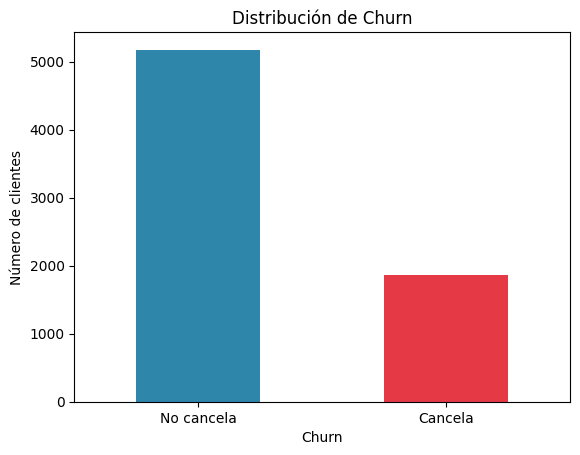

In [9]:
df['Churn'].value_counts().plot(kind='bar', color=['#2E86AB', '#E63946'])
plt.title('Distribución de Churn')
plt.xticks([0, 1], ['No cancela', 'Cancela'], rotation=0)
plt.ylabel('Número de clientes')
plt.show()

El dataset está **desbalanceado**: 5,174 clientes (73.5%) permanecen activos frente a 1,869 (26.5%) que cancelan el servicio. Este desbalance es la razón principal por la que se reporta ROC-AUC y F1-score además de Accuracy: con este nivel de desbalance, un modelo trivial que siempre prediga "no cancela" ya alcanzaría ~73.5% de exactitud sin ningún valor predictivo real.

### Variables numéricas

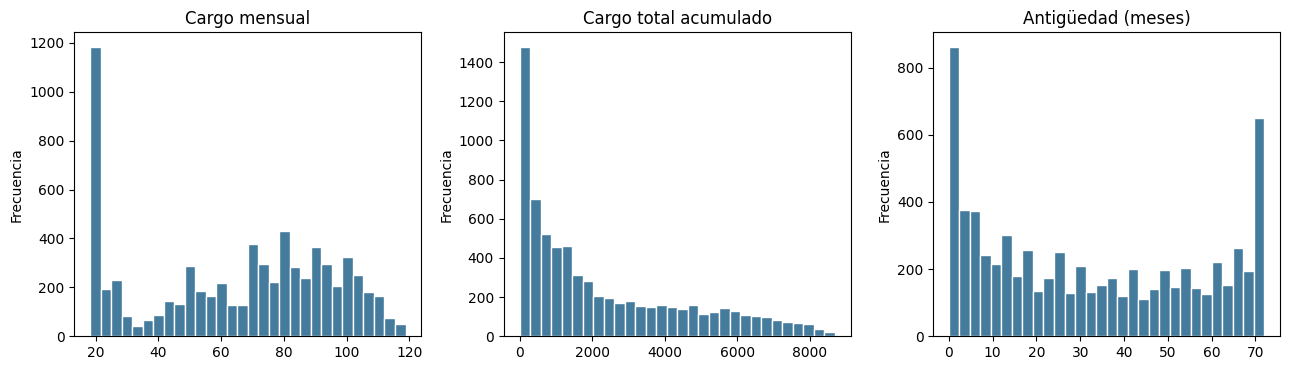

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col, title in zip(axes, ['MonthlyCharges', 'TotalCharges', 'tenure_months'],
                           ['Cargo mensual', 'Cargo total acumulado', 'Antigüedad (meses)']):
    ax.hist(df[col], bins=30, color='#457B9D', edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

- **`MonthlyCharges`** se concentra en dos rangos: un grupo grande de clientes con cargos bajos (~20 USD, típicamente sin internet) y otro entre 70 y 100 USD (con internet y servicios adicionales).
- **`TotalCharges`** presenta una distribución asimétrica hacia la derecha: la mayoría de los clientes acumula cargos totales bajos (clientes más nuevos) y pocos clientes llevan cargos muy altos (clientes de mayor antigüedad).
- **`tenure_months`** muestra dos picos claros: muchos clientes muy nuevos (0–5 meses) y otro grupo importante con más de 60 meses de antigüedad, lo que sugiere dos perfiles de cliente distintos: los que cancelan pronto y los que permanecen a largo plazo.

### Tasa de cancelación por variable categórica

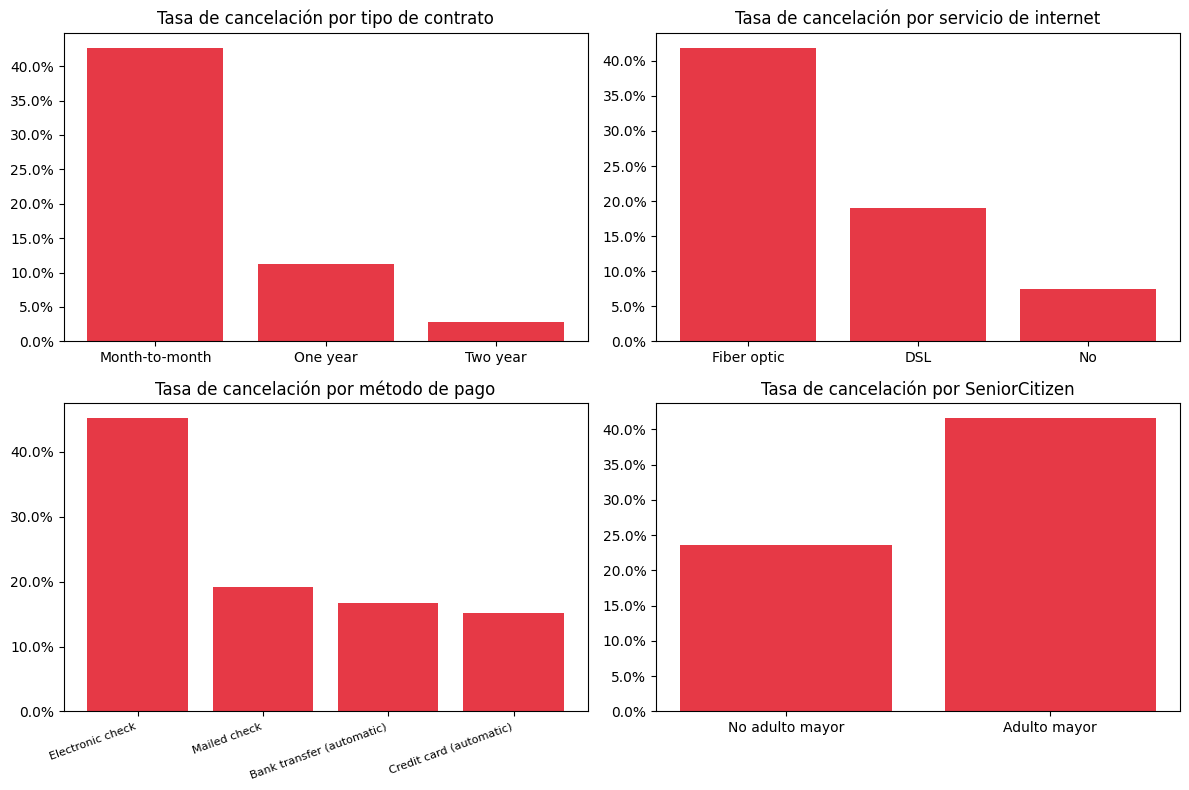

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

d = df.groupby('Type')['Churn'].mean().sort_values(ascending=False)
axes[0,0].bar(d.index, d.values, color='#E63946')
axes[0,0].set_title('Tasa de cancelación por tipo de contrato')
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

d = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)
axes[0,1].bar(d.index, d.values, color='#E63946')
axes[0,1].set_title('Tasa de cancelación por servicio de internet')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

d = df.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)
axes[1,0].bar(range(len(d)), d.values, color='#E63946')
axes[1,0].set_xticks(range(len(d)))
axes[1,0].set_xticklabels(d.index, rotation=20, ha='right', fontsize=8)
axes[1,0].set_title('Tasa de cancelación por método de pago')
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

d = df.groupby('SeniorCitizen')['Churn'].mean()
axes[1,1].bar(['No adulto mayor', 'Adulto mayor'], d.values, color='#E63946')
axes[1,1].set_title('Tasa de cancelación por SeniorCitizen')
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

**Hallazgos principales del EDA** (todas las diferencias son sustanciales y consistentes con la intuición de negocio):

- **Tipo de contrato**: los clientes *mes a mes* cancelan en un **42.7%** de los casos, frente a **11.3%** en contratos de un año y solo **2.8%** en contratos de dos años. Es, por lejos, la señal más fuerte de todo el análisis.
- **Servicio de internet**: los clientes con **fibra óptica** cancelan un **41.9%** de las veces, frente a **19.0%** con DSL y **7.4%** sin internet — posiblemente relacionado con precio o competencia en ese segmento.
- **Método de pago**: **cheque electrónico** tiene la tasa de cancelación más alta (**45.3%**), muy por encima de domiciliación bancaria (16.7%), tarjeta de crédito (15.2%) o cheque por correo (19.1%).
- **Adultos mayores**: cancelan en un **41.7%** de los casos frente a **23.6%** en el resto de los clientes.
- **Facturación sin papel** (`PaperlessBilling = Yes`): tasa de cancelación de **33.6%** frente a **16.3%**.
- **Antigüedad**: los clientes que cancelan llevan en promedio **18.0 meses**, frente a **37.6 meses** de los que permanecen — confirma que `tenure_months` es una variable con alto poder predictivo.
- **Cargo mensual**: los clientes que cancelan pagan en promedio **74.4 USD/mes**, frente a **61.3 USD/mes** de los que permanecen.

Estos patrones coinciden con la importancia de variables que se obtiene más adelante a partir del modelo final, lo que refuerza la validez del análisis.

## 6. Preparación de variables para el modelado

Se eliminan `customerID` (identificador, sin valor predictivo) y `BeginDate`/`EndDate` (se usaron para construir `Churn` y `tenure_months`, y mantenerlas causaría fuga de información directa hacia el objetivo). El preprocesamiento se encapsula en un `ColumnTransformer` dentro de un `Pipeline`, de modo que la imputación y el escalado/codificación se ajusten *solo* con datos de entrenamiento en cada validación cruzada, evitando fuga de información.

In [12]:
X = df.drop(columns=['customerID', 'BeginDate', 'EndDate', 'Churn'])
y = df['Churn']

num_cols = X.select_dtypes(exclude='object').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} filas | Prueba: {X_test.shape[0]} filas')
print(f'Tasa de Churn en entrenamiento: {y_train.mean():.3%}')
print(f'Tasa de Churn en prueba:        {y_test.mean():.3%}')

Entrenamiento: 5634 filas | Prueba: 1409 filas
Tasa de Churn en entrenamiento: 26.535%
Tasa de Churn en prueba:        26.544%


La división estratificada (`stratify=y`) mantiene la misma proporción de clases (~26.5% de cancelación) en ambos conjuntos, lo cual es importante dado el desbalance observado en el EDA.

## 7. Modelos base (parámetros por defecto)

Antes de invertir tiempo en el ajuste de hiperparámetros, se entrenan tres modelos de clasificación con sus parámetros por defecto, para tener una referencia de desempeño (*baseline*).

In [13]:
baseline_models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}

baseline_results = []
for name, model in baseline_models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    baseline_results.append([name, accuracy_score(y_test, pred), f1_score(y_test, pred), roc_auc_score(y_test, proba)])
    print(f'--- {name} ---')
    print(classification_report(y_test, pred, target_names=['No cancela', 'Cancela']))

baseline_df = pd.DataFrame(baseline_results, columns=['Modelo', 'Accuracy', 'F1', 'ROC_AUC']).sort_values('ROC_AUC', ascending=False)
baseline_df

--- LogisticRegression ---
              precision    recall  f1-score   support

  No cancela       0.85      0.89      0.87      1035
     Cancela       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

--- RandomForest ---
              precision    recall  f1-score   support

  No cancela       0.82      0.89      0.86      1035
     Cancela       0.62      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409

--- GradientBoosting ---
              precision    recall  f1-score   support

  No cancela       0.84      0.91      0.87      1035
     Cancela       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
w

,Modelo,Accuracy,F1,ROC_AUC
2,GradientBoosting,0.802697,0.581325,0.843319
0,LogisticRegression,0.804826,0.603175,0.841750
1,RandomForest,0.781405,0.533333,0.817108


Con parámetros por defecto, **GradientBoosting** obtiene el mejor ROC-AUC (0.8433), pero el F1-score para la clase "Cancela" ronda 0.53–0.60 en los tres modelos: hay margen de mejora claro, especialmente en el *recall* de la clase minoritaria. Esto motiva el ajuste de hiperparámetros de la siguiente sección.

## 8. Ajuste de hiperparámetros

Se optimiza cada modelo mediante validación cruzada estratificada (`StratifiedKFold`, 3 particiones) usando **ROC-AUC** como métrica objetivo, por ser robusta al desbalance de clases:

- **Regresión Logística** → `GridSearchCV` (espacio de búsqueda pequeño, se explora exhaustivamente).
- **Random Forest** y **Gradient Boosting** → `RandomizedSearchCV` (espacios de búsqueda más grandes; se muestrean combinaciones para mantener el tiempo de cómputo razonable).

In [14]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
tuned_estimators = {}

# --- Regresión Logística ---
pipe_lr = Pipeline([('pre', preprocessor), ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
param_lr = {'model__C': [0.01, 0.1, 1, 10], 'model__class_weight': [None, 'balanced']}
search_lr = GridSearchCV(pipe_lr, param_lr, scoring='roc_auc', cv=cv, n_jobs=-1)
search_lr.fit(X_train, y_train)
tuned_estimators['LogisticRegression'] = search_lr.best_estimator_
print('LogisticRegression | mejores parámetros:', search_lr.best_params_, '| ROC-AUC (CV):', round(search_lr.best_score_, 4))

# --- Random Forest ---
pipe_rf = Pipeline([('pre', preprocessor), ('model', RandomForestClassifier(random_state=RANDOM_STATE))])
param_rf = {
    'model__n_estimators': [150, 250, 350],
    'model__max_depth': [None, 8, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__class_weight': [None, 'balanced']
}
search_rf = RandomizedSearchCV(pipe_rf, param_rf, n_iter=8, scoring='roc_auc', cv=cv, random_state=RANDOM_STATE, n_jobs=-1)
search_rf.fit(X_train, y_train)
tuned_estimators['RandomForest'] = search_rf.best_estimator_
print('RandomForest | mejores parámetros:', search_rf.best_params_, '| ROC-AUC (CV):', round(search_rf.best_score_, 4))

# --- Gradient Boosting ---
pipe_gb = Pipeline([('pre', preprocessor), ('model', GradientBoostingClassifier(random_state=RANDOM_STATE))])
param_gb = {
    'model__n_estimators': [100, 150, 200],
    'model__learning_rate': [0.03, 0.05, 0.1, 0.2],
    'model__max_depth': [2, 3, 4],
    'model__subsample': [0.8, 0.9, 1.0]
}
search_gb = RandomizedSearchCV(pipe_gb, param_gb, n_iter=8, scoring='roc_auc', cv=cv, random_state=RANDOM_STATE, n_jobs=-1)
search_gb.fit(X_train, y_train)
tuned_estimators['GradientBoosting'] = search_gb.best_estimator_
print('GradientBoosting | mejores parámetros:', search_gb.best_params_, '| ROC-AUC (CV):', round(search_gb.best_score_, 4))

LogisticRegression | mejores parámetros: {'model__C': 10, 'model__class_weight': None} | ROC-AUC (CV): 0.846
RandomForest | mejores parámetros: {'model__n_estimators': 350, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 8, 'model__class_weight': 'balanced'} | ROC-AUC (CV): 0.8464
GradientBoosting | mejores parámetros: {'model__subsample': 0.8, 'model__n_estimators': 150, 'model__max_depth': 2, 'model__learning_rate': 0.05} | ROC-AUC (CV): 0.8495


## 9. Evaluación de los modelos ajustados sobre el conjunto de prueba

In [15]:
tuned_results = []
for name, est in tuned_estimators.items():
    pred = est.predict(X_test)
    proba = est.predict_proba(X_test)[:, 1]
    tuned_results.append([name, accuracy_score(y_test, pred), f1_score(y_test, pred), roc_auc_score(y_test, proba)])
    print(f'--- {name} (ajustado) ---')
    print(classification_report(y_test, pred, target_names=['No cancela', 'Cancela']))

tuned_df = pd.DataFrame(tuned_results, columns=['Modelo', 'Accuracy', 'F1', 'ROC_AUC']).sort_values('ROC_AUC', ascending=False)
tuned_df

--- LogisticRegression (ajustado) ---
              precision    recall  f1-score   support

  No cancela       0.85      0.90      0.87      1035
     Cancela       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

--- RandomForest (ajustado) ---
              precision    recall  f1-score   support

  No cancela       0.90      0.76      0.82      1035
     Cancela       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409

--- GradientBoosting (ajustado) ---
              precision    recall  f1-score   support

  No cancela       0.84      0.90      0.87      1035
     Cancela       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.7

,Modelo,Accuracy,F1,ROC_AUC
2,GradientBoosting,0.801278,0.580838,0.846549
1,RandomForest,0.760114,0.631004,0.842203
0,LogisticRegression,0.805536,0.602899,0.841386


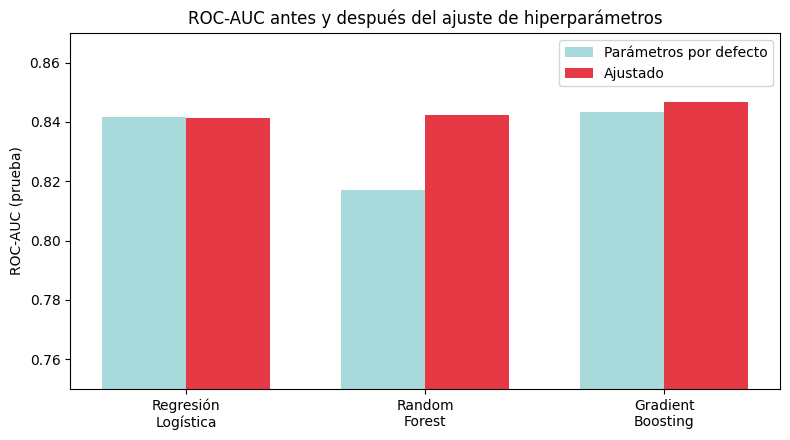

In [16]:
x = np.arange(3)
width = 0.35
order = ['LogisticRegression', 'RandomForest', 'GradientBoosting']
b = baseline_df.set_index('Modelo').loc[order, 'ROC_AUC']
t = tuned_df.set_index('Modelo').loc[order, 'ROC_AUC']

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width/2, b.values, width, label='Parámetros por defecto', color='#A8DADC')
ax.bar(x + width/2, t.values, width, label='Ajustado', color='#E63946')
ax.set_xticks(x)
ax.set_xticklabels(['Regresión\nLogística', 'Random\nForest', 'Gradient\nBoosting'])
ax.set_ylabel('ROC-AUC (prueba)')
ax.set_title('ROC-AUC antes y después del ajuste de hiperparámetros')
ax.set_ylim(0.75, 0.87)
ax.legend()
plt.tight_layout()
plt.show()

El ajuste de hiperparámetros mejora el ROC-AUC de los tres modelos, aunque en distinta magnitud:

- **Random Forest** es el que más se beneficia (0.8171 → 0.8422, **+0.025**), impulsado principalmente por `class_weight='balanced'`, que corrige el sesgo hacia la clase mayoritaria: su F1 para la clase "Cancela" sube de 0.53 a **0.63**, el más alto de los tres modelos, a costa de un *accuracy* algo menor.
- **Gradient Boosting** mejora ligeramente (0.8433 → 0.8465) y se mantiene como el modelo con mayor ROC-AUC en el conjunto de prueba.
- **Regresión Logística** se mantiene prácticamente estable (0.8417 → 0.8414); ya rendía cerca de su techo con los parámetros por defecto.

### Curvas ROC

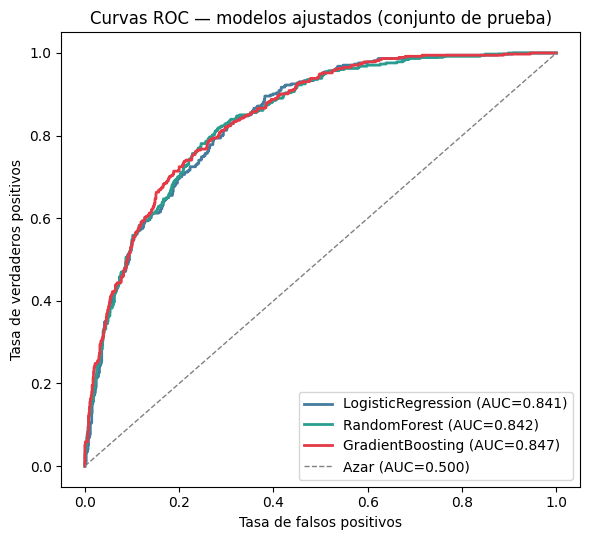

In [17]:
fig, ax = plt.subplots(figsize=(6, 5.5))
colors = {'LogisticRegression': '#457B9D', 'RandomForest': '#2A9D8F', 'GradientBoosting': '#E63946'}
for name, est in tuned_estimators.items():
    proba = est.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=colors[name], linewidth=2)
ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='Azar (AUC=0.500)')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curvas ROC — modelos ajustados (conjunto de prueba)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

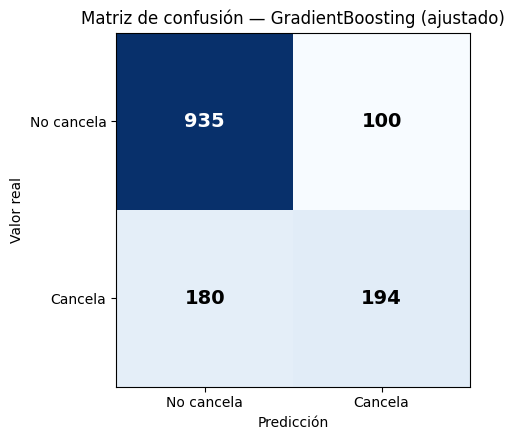

In [18]:
best_name = tuned_df.iloc[0]['Modelo']
best_model = tuned_estimators[best_name]
pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred_best)
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['No cancela', 'Cancela']); ax.set_yticklabels(['No cancela', 'Cancela'])
ax.set_xlabel('Predicción'); ax.set_ylabel('Valor real')
ax.set_title(f'Matriz de confusión — {best_name} (ajustado)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

De 374 clientes que efectivamente cancelaron en el conjunto de prueba, el modelo final identifica correctamente a **194** (*recall* ≈ 52%) y deja **180 falsos negativos** (clientes que cancelan sin ser detectados). Desde la perspectiva de negocio, cada falso negativo es una oportunidad de retención perdida, mientras que un falso positivo implica, como mucho, ofrecer una promoción a un cliente que de todas formas iba a quedarse. Este costo asimétrico es el motivo por el que, en la sección de conclusiones, se plantea a Random Forest (mayor *recall*) como alternativa a evaluar frente a Gradient Boosting (mayor ROC-AUC global).

### Importancia de variables

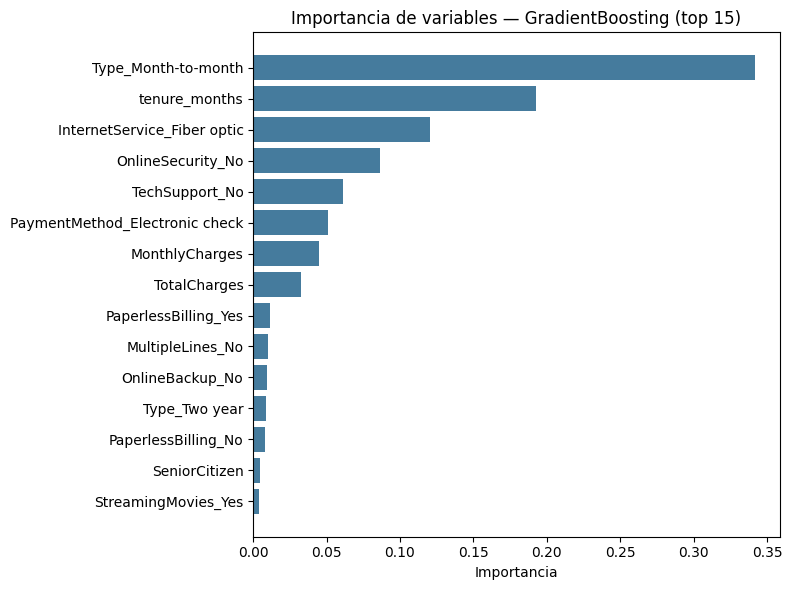

In [19]:
ohe = best_model.named_steps['pre'].named_transformers_['cat'].named_steps['onehot']
feature_names = num_cols + list(ohe.get_feature_names_out(cat_cols))
importances = best_model.named_steps['model'].feature_importances_

imp_df = (pd.DataFrame({'feature': feature_names, 'importance': importances})
          .sort_values('importance', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='#457B9D')
ax.set_title(f'Importancia de variables — {best_name} (top 15)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

Las variables más relevantes para el modelo final coinciden con los patrones detectados en el EDA: **tipo de contrato mes a mes**, **antigüedad del cliente** (`tenure_months`, la variable creada en este proyecto, es la 2ª más importante) y **servicio de internet por fibra óptica** concentran la mayor parte del poder predictivo, seguidas de la ausencia de seguridad en línea (`OnlineSecurity_No`), soporte técnico (`TechSupport_No`) y el pago por cheque electrónico.

## 10. Comparación final y selección del modelo

In [20]:
tuned_df_sorted = tuned_df.sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
display(tuned_df_sorted)
print('Mejor modelo por ROC-AUC:', tuned_df_sorted.iloc[0]['Modelo'])

,Modelo,Accuracy,F1,ROC_AUC
0,GradientBoosting,0.801278,0.580838,0.846549
1,RandomForest,0.760114,0.631004,0.842203
2,LogisticRegression,0.805536,0.602899,0.841386


Mejor modelo por ROC-AUC: GradientBoosting


## Conclusiones

Se desarrolló un modelo de aprendizaje automático para predecir la cancelación de clientes (`Churn`) de Interconnect a partir de información contractual, demográfica y de los servicios contratados. El trabajo incluyó:

1. **Integración de datos**: se combinaron las cuatro tablas mediante `customerID`, usando `left join` para `internet` y `phone` dado que no todos los clientes contratan esos servicios.
2. **Tratamiento de nulos**: los valores nulos que aparecieron tras la integración (1,526 clientes sin internet, 682 sin teléfono, 11 sin cargos acumulados) se trataron de forma explícita según su causa, en lugar de imputarlos genéricamente, preservando información relevante para el modelo.
3. **Variable adicional**: se construyó `tenure_months` (antigüedad en meses) a partir de `BeginDate`/`EndDate`; resultó ser la 2ª variable más importante del modelo final.
4. **Análisis exploratorio**: reveló que el tipo de contrato mes a mes, el servicio de fibra óptica, el pago por cheque electrónico, ser adulto mayor y la baja antigüedad están fuertemente asociados a la cancelación.
5. **Modelado**: se entrenaron y compararon tres modelos (Regresión Logística, Random Forest y Gradient Boosting), primero con parámetros por defecto y luego con ajuste de hiperparámetros mediante `GridSearchCV`/`RandomizedSearchCV` y validación cruzada estratificada.

**Resultado final** (conjunto de prueba, modelos ajustados):

| Modelo | Accuracy | F1 | ROC-AUC |
|---|---|---|---|
| **Gradient Boosting** | 0.8013 | 0.5808 | **0.8465** |
| Random Forest | 0.7601 | **0.6310** | 0.8422 |
| Regresión Logística | 0.8055 | 0.6029 | 0.8414 |

**Gradient Boosting** (`learning_rate=0.05`, `max_depth=2`, `n_estimators=150`, `subsample=0.8`) es el modelo con mejor ROC-AUC (0.8465) y se recomienda como modelo principal para estimar la probabilidad de cancelación de cada cliente. Sin embargo, **Random Forest ajustado con `class_weight='balanced'`** logra el F1-score más alto (0.6310) gracias a un mayor *recall* sobre los clientes que sí cancelan — es decir, comete menos falsos negativos. Dado que en un problema de retención el costo de **no detectar** a un cliente que va a cancelar suele ser mayor que el costo de ofrecerle una promoción a alguien que iba a quedarse, se recomienda:

- Usar **Gradient Boosting** para el *ranking*/*scoring* general de riesgo de cancelación (mejor discriminación global, medida por ROC-AUC).
- Evaluar **Random Forest balanceado**, o ajustar el umbral de decisión de Gradient Boosting por debajo de 0.5, si el objetivo de negocio prioriza capturar la mayor cantidad posible de clientes en riesgo, aun a costa de más falsos positivos.

**Recomendaciones de negocio:**

- Priorizar campañas de retención en clientes con **contrato mes a mes**, **fibra óptica**, **pago por cheque electrónico** y **menos de ~18 meses de antigüedad**: es el perfil de mayor riesgo identificado tanto en el EDA como en la importancia de variables del modelo.
- Incentivar la migración a contratos de mayor plazo (anual o bianual), dado que reducen drásticamente la tasa de cancelación observada (de 42.7% a 2.8%).
- Explorar por qué el segmento de fibra óptica y el pago por cheque electrónico presentan tasas de cancelación tan altas (precio, competencia, fricción en el proceso de pago), ya que son palancas de negocio, no solo señales predictivas.

**Próximos pasos sugeridos:** ampliar la búsqueda de hiperparámetros (más iteraciones/folds), probar el ajuste del umbral de clasificación en función del costo de negocio de cada tipo de error, y monitorear el modelo en producción para reentrenarlo periódicamente a medida que cambien los patrones de cancelación.